In [1]:
!pip install monai loguru kagglehub scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.0 MB/s eta 0:00:00


In [2]:
import os
import kagglehub

DATA_DIR = kagglehub.dataset_download("briscdataset/brisc2025")
print(f"Dataset downloaded to: {DATA_DIR}")

Dataset downloaded to: /kaggle/input/datasets/briscdataset/brisc2025


In [3]:
import glob
import time
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
from loguru import logger
from monai.networks.nets import AttentionUnet
from monai.networks.layers import Norm
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.networks.utils import one_hot
from monai.transforms import (
    Compose, RandAffined, RandAdjustContrastd, RandFlipd,
    EnsureTyped, CastToTyped, NormalizeIntensityd,
)

# Configuration
CONFIG = {
    "data_dir": DATA_DIR,
    "batch_size": 16,
    "image_size": (512, 512),
    "learning_rate_seg": 1e-4,
    "val_split": 0.2,
    "seg_channels": (32, 64, 128, 256, 512, 1024),
    "seg_strides": (2, 2, 2, 2, 2),
    "seg_in_channels": 3,
    "seg_out_channels": 2,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

print(f"Device: {CONFIG['device']}")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-07 10:25:40.056296: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778149540.243328      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778149540.299056      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778149540.772919      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778149540.772955      57 computation_placer.cc:1

Device: cuda


In [4]:
class BRISCSegDataset(Dataset):
    def __init__(self, image_dir=None, mask_dir=None, image_size=(512, 512), augment=False):
        self.image_size = image_size
        self.augment = augment
        self.pairs = []

        if image_dir is not None and mask_dir is not None:
            image_path_obj = Path(image_dir)
            mask_path_obj = Path(mask_dir)
            for img_path in sorted(image_path_obj.glob("*.jpg")):
                mask_path = mask_path_obj / (img_path.stem + ".png")
                if mask_path.exists():
                    self.pairs.append((str(img_path), str(mask_path)))

        self.val_transform = Compose([
            NormalizeIntensityd(keys=["image"], channel_wise=True),
            CastToTyped(keys=["label"], dtype=np.int64),
            EnsureTyped(keys=["image", "label"])
        ])

    def __len__(self):
        return len(self.pairs)

    def _load_image(self, path):
        img = Image.open(path).convert("RGB")
        img = img.resize(self.image_size, Image.BILINEAR)
        return np.array(img, dtype=np.float32).transpose(2, 0, 1)

    def _load_mask(self, path):
        mask = Image.open(path).convert("L")
        mask = mask.resize(self.image_size, Image.NEAREST)
        arr = np.array(mask)
        return (arr > 127).astype(np.float32)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        data_dict = {
            "image": self._load_image(img_path),
            "label": self._load_mask(mask_path)[None, ...]
        }
        data_dict = self.val_transform(data_dict)
        return data_dict["image"], data_dict["label"]

In [5]:
from sklearn.model_selection import train_test_split

def discover_segmentation_data(data_dir):
    data_path = Path(data_dir)
    seg_dirs = list(data_path.rglob("segmentation_task"))
    seg_root = seg_dirs[0]
    train_img = seg_root / "train" / "images"
    train_mask = seg_root / "train" / "masks"
    test_img = seg_root / "test" / "images"
    test_mask = seg_root / "test" / "masks"
    return str(train_img), str(train_mask), str(test_img), str(test_mask)

train_img_dir, train_mask_dir, test_img_dir, test_mask_dir = discover_segmentation_data(CONFIG["data_dir"])

# Create Test Dataset & Loader
test_seg = BRISCSegDataset(test_img_dir, test_mask_dir, 
                          image_size=CONFIG["image_size"], augment=False)

test_loader = DataLoader(test_seg, 
                        batch_size=CONFIG["batch_size"], 
                        shuffle=False, 
                        num_workers=4, 
                        pin_memory=True)

print(f"Test set size: {len(test_seg)} images")

Test set size: 860 images


In [6]:
seg_model = AttentionUnet(
    spatial_dims=2,
    in_channels=CONFIG["seg_in_channels"],
    out_channels=CONFIG["seg_out_channels"],
    channels=CONFIG["seg_channels"],
    strides=CONFIG["seg_strides"],
    dropout=0.3,
).to(CONFIG['device'])

print(f"Model parameters: {sum(p.numel() for p in seg_model.parameters()):,}")

Model parameters: 31,805,446


Running full analysis with plots...

🎯 DICE ANALYSIS REPORT
Total images                  : 860
Mean Dice                     : 0.8698
Median Dice                   : 0.9360
Std Dev                       : 0.1736
-------------------------------------------------------------------------------------
Bad cases       (Dice < 0.65)          :   76  ( 8.84%)
Good cases    (0.65 ≤ Dice < 0.85)   :  131  (15.23%)
Excellent cases    (Dice ≥ 0.85)          :  653  (75.93%)


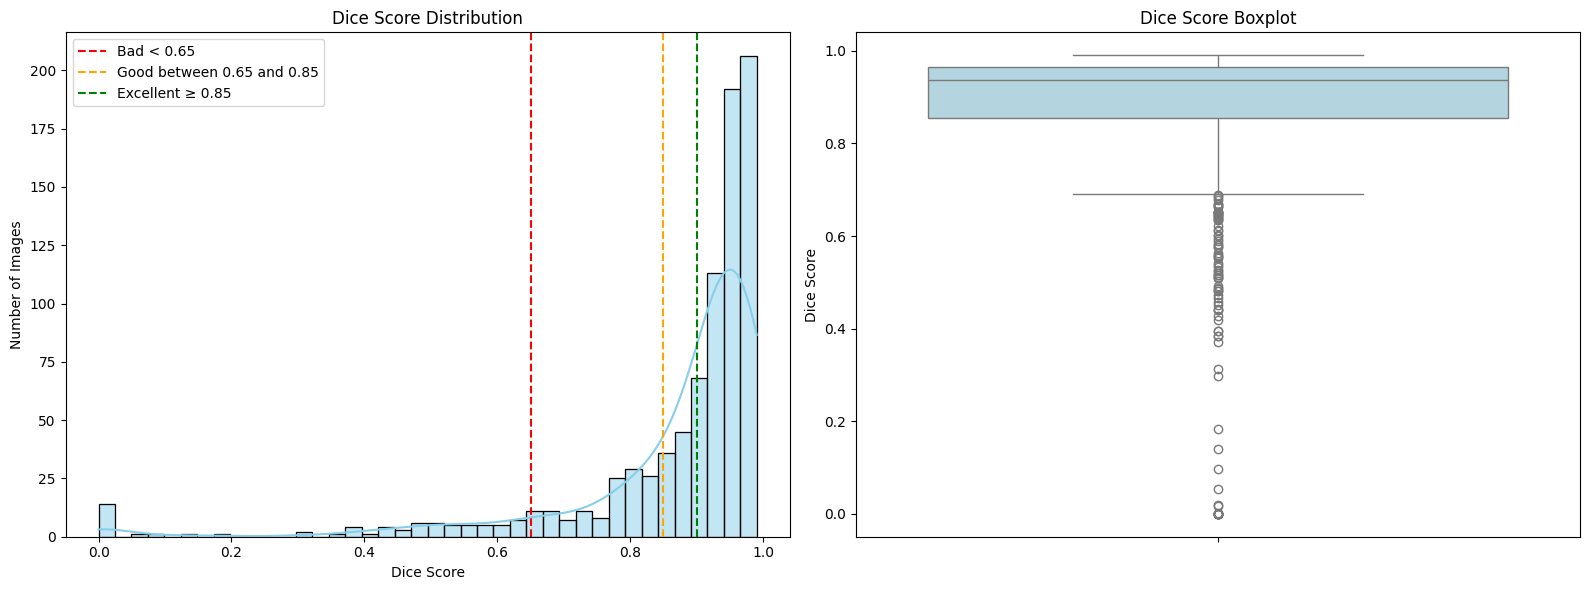


🔥 Top 10 Excellent Cases (Dice ≥ 0.90):
   brisc2025_test_00718_pi_ax_t1.jpg        → Dice: 0.9904
   brisc2025_test_00547_me_sa_t1.jpg        → Dice: 0.9893
   brisc2025_test_00554_me_sa_t1.jpg        → Dice: 0.9891
   brisc2025_test_00540_me_sa_t1.jpg        → Dice: 0.9891
   brisc2025_test_00498_me_sa_t1.jpg        → Dice: 0.9890
   brisc2025_test_00468_me_co_t1.jpg        → Dice: 0.9886
   brisc2025_test_00798_pi_ax_t1.jpg        → Dice: 0.9883
   brisc2025_test_00287_me_ax_t1.jpg        → Dice: 0.9878
   brisc2025_test_00346_me_ax_t1.jpg        → Dice: 0.9873
   brisc2025_test_00736_pi_ax_t1.jpg        → Dice: 0.9871

❌ Top 10 Worst Cases (Dice < 0.65):
   brisc2025_test_00001_gl_ax_t1.jpg        → Dice: 0.0000
   brisc2025_test_00005_gl_ax_t1.jpg        → Dice: 0.0000
   brisc2025_test_00007_gl_ax_t1.jpg        → Dice: 0.0000
   brisc2025_test_00011_gl_ax_t1.jpg        → Dice: 0.0000
   brisc2025_test_00012_gl_ax_t1.jpg        → Dice: 0.0000
   brisc2025_test_00017_gl_ax_t1.jpg 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from monai.metrics import DiceMetric
from monai.networks.utils import one_hot
import torch
from pathlib import Path


# Load best model
seg_model.load_state_dict(torch.load("/kaggle/input/datasets/rabiebeltaief/segmentation-pth/segmentation.pth", map_location=CONFIG['device']))
seg_model.eval()

dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)

all_dices = []
bad_cases = []
good_cases = []     
excellent_cases = [] 

print("Running full analysis with plots...\n")

with torch.no_grad():
    for idx, (images, masks) in enumerate(test_loader):
        images = images.to(CONFIG['device'])
        masks = masks.to(CONFIG['device'])
        
        with torch.amp.autocast("cuda"):
            outputs = seg_model(images)
        
        preds = torch.argmax(outputs, dim=1, keepdim=True)
        
        pred_oh = one_hot(preds, num_classes=CONFIG["seg_out_channels"])
        mask_oh = one_hot(masks, num_classes=CONFIG["seg_out_channels"])
        
        dice_metric(pred_oh, mask_oh)
        batch_dices = dice_metric.aggregate(reduction="none").cpu().numpy().flatten()
        dice_metric.reset()
        
        for i, dice in enumerate(batch_dices):
            global_idx = idx * CONFIG["batch_size"] + i
            img_name = Path(test_seg.pairs[global_idx][0]).name
            
            all_dices.append(dice)
            
            if dice < 0.65:
                bad_cases.append({'name': img_name, 'dice': float(dice)})
            elif 0.65 < dice < 0.85:
                good_cases.append({'name': img_name, 'dice': float(dice)})
            else:
                excellent_cases.append({'name': img_name, 'dice': float(dice)})

# ============================
# SUMMARY
# ============================
all_dices = np.array(all_dices)
total = len(all_dices)

bad_count = len(bad_cases)
good_count = len(good_cases)
excellent_count = len(excellent_cases)

print(f"{'='*85}")
print(f"🎯 DICE ANALYSIS REPORT")
print(f"{'='*85}")
print(f"Total images                  : {total}")
print(f"Mean Dice                     : {all_dices.mean():.4f}")
print(f"Median Dice                   : {np.median(all_dices):.4f}")
print(f"Std Dev                       : {all_dices.std():.4f}")
print(f"{'-'*85}")

print(f"Bad cases       (Dice < 0.65)          : {bad_count:4d}  ({bad_count/total*100:5.2f}%)")
print(f"Good cases    (0.65 ≤ Dice < 0.85)   : {good_count:4d}  ({good_count/total*100:5.2f}%)")
print(f"Excellent cases    (Dice ≥ 0.85)          : {excellent_count:4d}  ({(excellent_count)/total*100:5.2f}%)")
print(f"{'='*85}")

# ============================
# PLOTS
# ============================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
sns.histplot(all_dices, bins=40, kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(x=0.65, color='red', linestyle='--', label='Bad < 0.65')
axes[0].axvline(x=0.85, color='orange', linestyle='--', label='Good between 0.65 and 0.85')
axes[0].axvline(x=0.90, color='green', linestyle='--', label='Excellent ≥ 0.85')
axes[0].set_title('Dice Score Distribution')
axes[0].set_xlabel('Dice Score')
axes[0].set_ylabel('Number of Images')
axes[0].legend()

# Boxplot
sns.boxplot(y=all_dices, ax=axes[1], color='lightblue')
axes[1].set_title('Dice Score Boxplot')
axes[1].set_ylabel('Dice Score')

plt.tight_layout()
plt.show()

# ============================
# TOP CASES
# ============================
print(f"\n🔥 Top 10 Excellent Cases (Dice ≥ 0.90):")
excellent_cases.sort(key=lambda x: x['dice'], reverse=True)
for case in excellent_cases[:10]:
    print(f"   {case['name']:40} → Dice: {case['dice']:.4f}")

print(f"\n❌ Top 10 Worst Cases (Dice < 0.65):")
bad_cases.sort(key=lambda x: x['dice'])
for case in bad_cases[:10]:
    print(f"   {case['name']:40} → Dice: {case['dice']:.4f}")